# 1 - Network flow based anomaly detector for CICIDS2017
This notebook provides a sample implementation of a flow-based network anomaly detector, which main mission is to tag each network flow with a anomaly index, a number from 0 to 1, indicating the probability that the flow belongs to an attack according to the OD algorithm. This implementation will use [CICIDS2017](https://www.unb.ca/cic/datasets/ids-2017.html) as dataset of reference.

## 1.1 - Preliminary actions

### 1.1.1 - Validate downloaded files

In [46]:
import os

for root, dirs, files in os.walk('./CSVs'):
        print(root+":")
        if dirs:
            print('\n'.join(dirs))
        if files:
            print('\n'.join(files))
            

./CSVs:
TrafficLabelling 
MachineLearningCVE
./CSVs/TrafficLabelling :
.ipynb_checkpoints
Friday-WorkingHours-Morning.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
./CSVs/TrafficLabelling /.ipynb_checkpoints:
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX-checkpoint.csv
./CSVs/MachineLearningCVE:
.ipynb_checkpoints
Friday-WorkingHours-Morning.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Merged.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
./CSVs/MachineLear

### 1.1.2 - Inspect csv file columns

In [47]:
import csv

files=os.listdir('./CSVs/MachineLearningCVE')
for file in files:
    if file.endswith(".csv"):
        print("\n"+file+"\n")
        with open(f"./CSVs/MachineLearningCVE/{file}", newline="") as f:
            r=csv.DictReader(f)
            print('\n'.join(name.strip() for name in r.fieldnames))
        


Friday-WorkingHours-Morning.pcap_ISCX.csv

Destination Port
Flow Duration
Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Average Packet Size
Avg Fwd Segment Size
Avg Bwd Segment Size
Fwd Header Length
Fwd Avg Bytes

## 1.2 - Data Formatting

### 1.2.1 - Dataframe merging

In [48]:
import pandas as pd

df_list=[]
for file in files:
    if file.endswith(".csv") and not file=="Merged.csv":
        df_list.append(pd.read_csv(f"./CSVs/MachineLearningCVE/{file}"))
df=pd.concat(df_list)
df.columns = df.columns.str.strip()
df.info()
print()
print(df['Label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2830743 entries, 0 to 286466
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  F

### 1.2.2 - Categorical Encoding

In [ ]:
# save the actual label of the attacks in a separate variable for later use
Label_col=df['Label']

In [ ]:
# replace the attack labels with 1 and the benign label with 0 for anomaly detection
df['Label'] = df['Label'].replace('DoS Hulk', 1) 
df['Label'] = df['Label'].replace('PortScan', 1) 
df['Label'] = df['Label'].replace('DDoS', 1) 
df['Label'] = df['Label'].replace('DoS GoldenEye', 1) 
df['Label'] = df['Label'].replace('FTP-Patator', 1) 
df['Label'] = df['Label'].replace('SSH-Patator', 1) 
df['Label'] = df['Label'].replace('DoS slowloris', 1) 
df['Label'] = df['Label'].replace('DoS Slowhttptest', 1) 
df['Label'] = df['Label'].replace('Bot', 1) 
df['Label'] = df['Label'].replace('Web Attack � Brute Force', 1) 
df['Label'] = df['Label'].replace('Web Attack � XSS', 1) 
df['Label'] = df['Label'].replace('Infiltration', 1) 
df['Label'] = df['Label'].replace('Web Attack � Sql Injection', 1) 
df['Label'] = df['Label'].replace('Heartbleed', 1) 
df['Label'] = df['Label'].replace('BENIGN', 0) 
df['Label'] = pd.to_numeric(df['Label'])
print(df['Label'].value_counts())

0    2273097
1     557646
Name: Label, dtype: int64


In [ ]:
# replace each attack label with an unique number for attack type mapping
mapping_dict={
    'BENIGN': 0,
    'DoS Hulk': 1,
    'PortScan': 2,
    'DDoS': 3,
    'DoS GoldenEye': 4,
    'FTP-Patator': 5,
    'SSH-Patator': 6,
    'DoS slowloris': 7,
    'DoS Slowhttptest': 8,
    'Bot': 9,
    'Web Attack � Brute Force': 10,
    'Web Attack � XSS': 11,
    'Infiltration': 12,
    'Web Attack � Sql Injection': 13,
    'Heartbleed': 14
}

### 1.2.3 - Handling infinite values

In [50]:
print(df.columns[np.isinf(df).any(axis=0)])
df=df.replace([np.inf, -np.inf, np.nan], -1)
print(df.columns[np.isinf(df).any(axis=0)])

Index(['Flow Bytes/s', 'Flow Packets/s'], dtype='object')
Index([], dtype='object')


### 1.2.3 - Saving dataframe

In [51]:
df.info()
df.to_csv("./CSVs/MachineLearningCVE/Merged.csv",index=False)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2830743 entries, 0 to 286466
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  F

## 1.3 - Feature engineering

### 1.3.1 - Load dataset

In [52]:
import numpy as np
import pandas as pd
df=pd.read_csv("./CSVs/MachineLearningCVE/Merged.csv")
print(df.columns[np.isinf(df).any(axis=0)])
y,X=df["Label"],df.drop("Label",axis=1)
columns=X.columns
print(columns)
print("contamination: ")
print(y.value_counts().get(1)/len(y))

Index([], dtype='object')
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag C

### 1.3.2 - Standardization

In [53]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
np_X=scaler.fit_transform(X)
X=pd.DataFrame(np_X, columns=columns)

## 1.4 - Training the classifiers

### 1.4.1 - Train-test split

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 1.4.2 - Train XGBoost

In [55]:
from xgboost import XGBClassifier
xgboost=XGBClassifier(n_estimators=50, random_state=42)
xgboost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=50, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

### 1.4.3 - Train IForest

In [56]:
from pyod.models.iforest import IForest
iforest=IForest(contamination=0.2, n_estimators=500,  n_jobs=10)
iforest.fit(X_train)

IForest(behaviour='old', bootstrap=False, contamination=0.2, max_features=1.0,
    max_samples='auto', n_estimators=500, n_jobs=10, random_state=None,
    verbose=0)

### 1.4.4 - Train INNE

In [57]:
from pyod.models.inne import INNE
inne=INNE(contamination=0.2, n_estimators=500)
inne.fit(X_train)

INNE(contamination=0.2, max_samples='auto', n_estimators=500,
   random_state=None)

### 1.4.5 - Train LDA

In [58]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda=LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

## 1.5 - Testing the classifiers

### 1.5.1 - Test XGBoost 

In [59]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
y_pred=xgboost.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print(f"xgboost test accuracy: {acc:.3f}")
rec=recall_score(y_test, y_pred)
print(f"xgboost test recall: {rec:.3f}")

xgboost test accuracy: 0.999
xgboost test recall: 0.999


### 1.5.2 - Test IForest

In [60]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
y_pred=iforest.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print(f"IForest test accuracy: {acc:.3f}")
rec=recall_score(y_test, y_pred)
print(f"IForest test recall: {rec:.3f}")

/home/zhang/anaconda3/envs/space_paper/lib/python3.10/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


IForest test accuracy: 0.768
IForest test recall: 0.419


### 1.5.3 - Test INNE

In [61]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
y_pred=inne.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print(f"INNE test accuracy: {acc:.3f}")
rec=recall_score(y_test, y_pred)
print(f"INNE test recall: {rec:.3f}")

INNE test accuracy: 0.715
INNE test recall: 0.285


### 1.5.4 - Test LDA

In [62]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
y_pred=lda.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print(f"LDA test accuracy: {acc:.3f}")
rec=recall_score(y_test, y_pred)
print(f"LDA test recall: {rec:.3f}")

LDA test accuracy: 0.898
LDA test recall: 0.580


### 1.5.5 - ROC and Precision-Recall curve for XGBoost

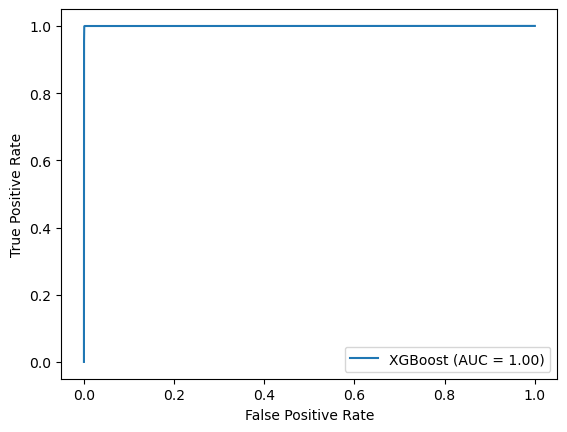

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob=xgboost.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="XGBoost")
displ.plot()
plt.show()

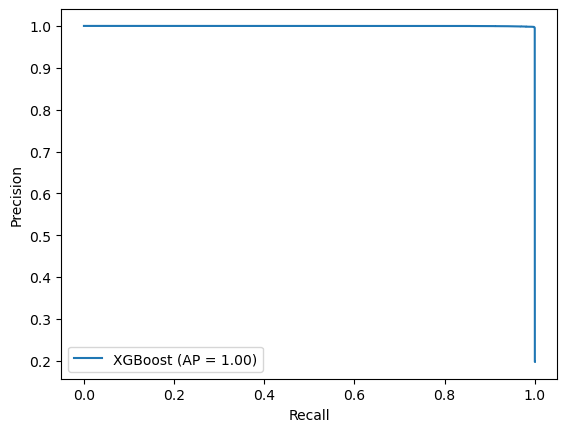

In [64]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

pre, rec, _ = precision_recall_curve(y_test, y_prob)
avg_pre = average_precision_score(y_test, y_prob)
disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="XGBoost")
disp.plot()
plt.show()

### 1.5.6 - ROC and Precision-Recall curve for IForest

/home/zhang/anaconda3/envs/space_paper/lib/python3.10/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


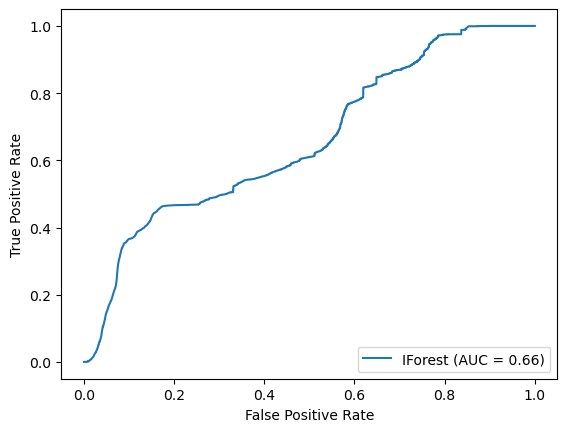

In [65]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob=iforest.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="IForest")
displ.plot()
plt.show()

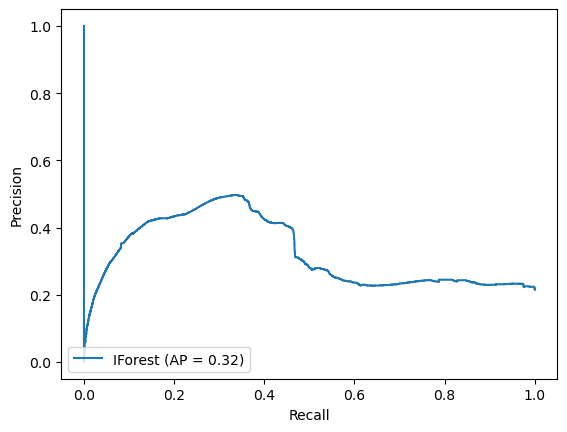

In [66]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

pre, rec, _ = precision_recall_curve(y_test, y_prob)
avg_pre = average_precision_score(y_test, y_prob)
disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="IForest")
disp.plot()
plt.show()

### 1.5.7 - ROC and Precision-Recall curve for INNE

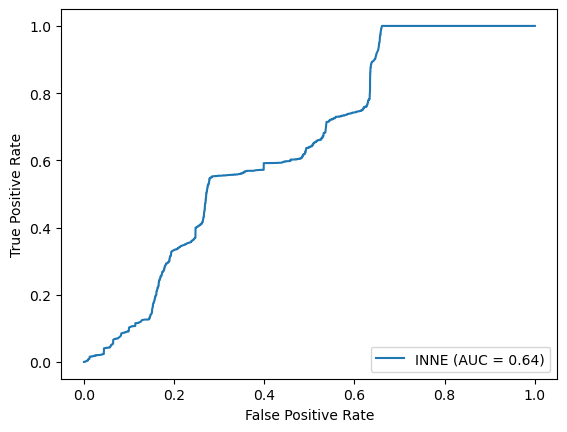

In [67]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob=inne.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="INNE")
displ.plot()
plt.show()

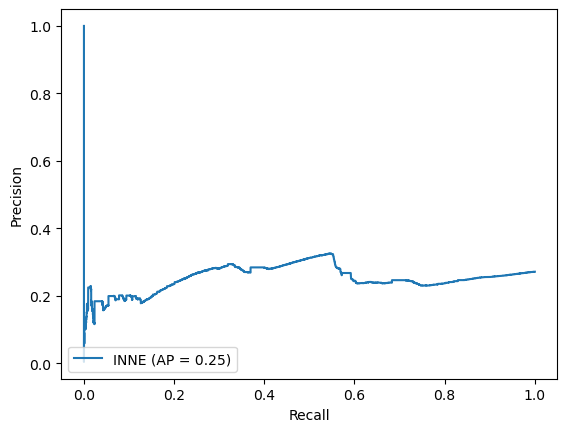

In [68]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

pre, rec, _ = precision_recall_curve(y_test, y_prob)
avg_pre = average_precision_score(y_test, y_prob)
disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="INNE")
disp.plot()
plt.show()

### 1.5.8 - ROC and Precision-Recall curve for LDA

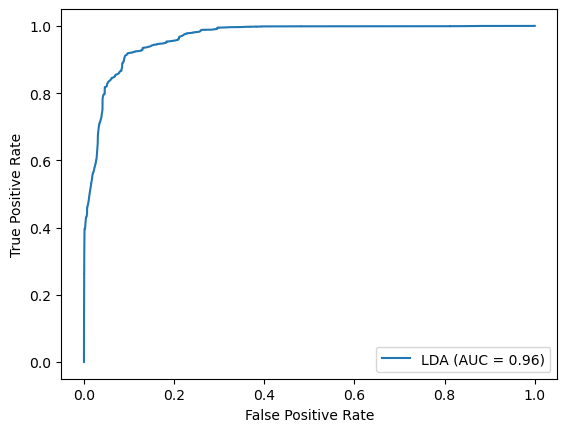

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob=lda.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="LDA")
displ.plot()
plt.show()

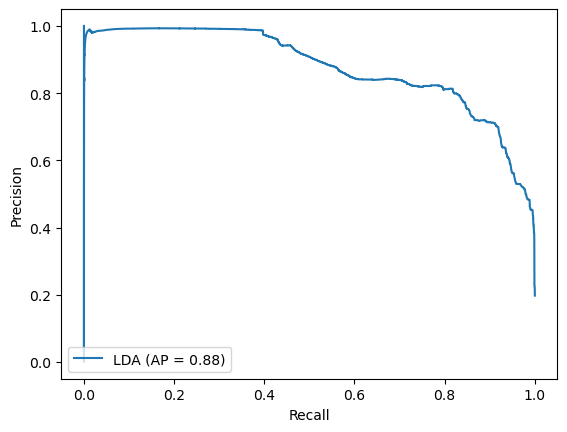

In [70]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

pre, rec, _ = precision_recall_curve(y_test, y_prob)
avg_pre = average_precision_score(y_test, y_prob)
disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="LDA")
disp.plot()
plt.show()

## 1.6 - Save The classifiers

In [ ]:
import pickle
from sklearn.pipeline import Pipeline
with open("Anomaly detectors/iforest.pkl", "wb") as f_iforest, open("Anomaly detectors/xgboost.pkl", "wb") as f_xgboost,  open("Anomaly detectors/inne.pkl", "wb") as f_inne,  open("Anomaly detectors/lda.pkl", "wb") as f_lda:
    pickle.dump(Pipeline([('scaler', scaler),('iforest', iforest)]), f_iforest)
    pickle.dump(Pipeline([('scaler', scaler),('xgboost', xgboost)]), f_xgboost)
    pickle.dump(Pipeline([('scaler', scaler),('inne', inne)]), f_inne)
    pickle.dump(Pipeline([('scaler', scaler),('lda', lda)]), f_lda)